# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename= "SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample.

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [119]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs.
* Compare the performance on training versus test sample. Are you over training?

In [120]:
# Used Google Colab for this lab, as tensor flow was included in it

In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Create a sequential model (layers stacked one after another)
model = Sequential()

model.add(Input(shape=(X_Train.shape[1],)))

# First hidden layer
# 32 neurons, ReLU activation
model.add(Dense(32, activation='relu'))

# Second hidden layer
model.add(Dense(16, activation='relu'))

# Output layer
# 1 neuron -> binary classification (signal vs background)
# sigmoid outputs probability between 0 and 1
model.add(Dense(1, activation='sigmoid'))

In [122]:
# Compile the model

model.compile(
    optimizer='adam',                 # optimization algorithm
    loss='binary_crossentropy',       # loss function for binary classification
    metrics=['accuracy']              # track accuracy during training
)

In [123]:
# Train the model
# This step learns patterns from the training data

history = model.fit(
    X_Train, y_Train,                 # training data
    epochs=10,                        # number of times model sees the data
    batch_size=256,                   # number of samples per update
    validation_data=(X_Test, y_Test)  # evaluate on test data each epoch
)

Epoch 1/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7835 - loss: 0.4594 - val_accuracy: 0.7956 - val_loss: 0.4411
Epoch 2/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7985 - loss: 0.4366 - val_accuracy: 0.7961 - val_loss: 0.4384
Epoch 3/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7992 - loss: 0.4345 - val_accuracy: 0.7963 - val_loss: 0.4386
Epoch 4/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7998 - loss: 0.4334 - val_accuracy: 0.7962 - val_loss: 0.4363
Epoch 5/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8006 - loss: 0.4324 - val_accuracy: 0.7990 - val_loss: 0.4337
Epoch 6/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8007 - loss: 0.4318 - val_accuracy: 0.7990 - val_loss: 0.4334
Epoch 7/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8010 - loss: 0.4314 - val_accuracy: 0.7981 - val_loss: 0.4334
Epoch 8/10
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8013 - loss: 0.4309 - 

In [124]:
def plot_history(history):

    # Get loss values
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Get accuracy values
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    # Epoch numbers
    epochs = range(1, len(loss) + 1)

    # ---- Plot Loss ----
    plt.figure()
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs Epochs')
    plt.show()

    # ---- Plot Accuracy ----
    plt.figure()
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs Epochs')
    plt.show()

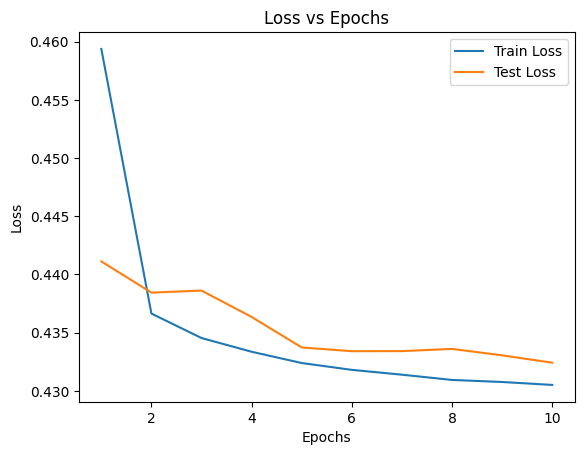

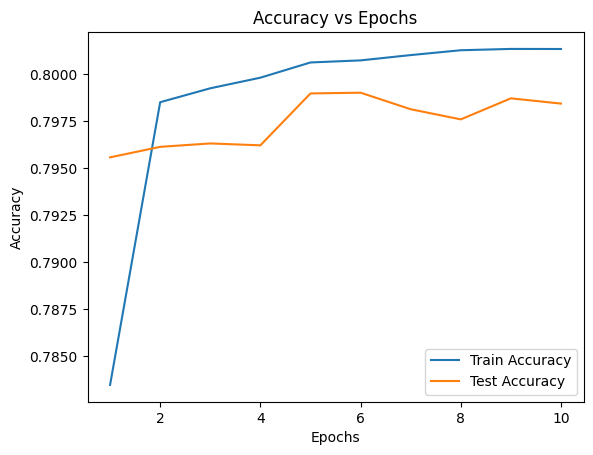

In [125]:
# Plot training results
plot_history(history)

In [126]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.783456,0.459371,0.79556,0.441115
1,0.798494,0.436634,0.79612,0.438436
2,0.799234,0.434533,0.79630,0.438609
3,0.799798,0.433354,0.79620,0.436343
4,0.800608,0.432385,0.79896,0.433723
5,0.800718,0.431798,0.79900,0.433402
6,0.801000,0.431383,0.79812,0.433408
7,0.801258,0.430932,0.79758,0.433598
8,0.801328,0.430756,0.79870,0.433046
9,0.801324,0.430504,0.79842,0.432415


In [127]:
# The model’s performance begins to plateau around epochs 6–8 since the
# validation loss stops improving significantly.

# The training and test results are very similar, so the model is not overtraining,
# although there is a slight sign of overfitting at the last epoch.

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [128]:
##### Original code (part I needed help on): splitting the data and training the model

##### Prompt: Evaluate the code and teach me how I can build on this code specifically how I can split the data and train the models

##### Explanation: I asked AI to help me build on top of what I had defined in accordance with Lab 7 and build on top so I can just fit the models and plot the ROC and AUC curves

In [129]:
# Raw variables (physics inputs only)
X_raw = np.array(df[RawNames])

# Engineered physics features
X_feat = np.array(df[FeatureNames])

# Combined dataset (raw + features)
X_all = np.array(df[VarNames[1:]])

In [130]:
# First N_Train samples are training data
# Remaining samples are test data

X_train_raw = X_raw[:N_Train]
X_test_raw = X_raw[N_Train:N_Max]

X_train_feat = X_feat[:N_Train]
X_test_feat = X_feat[N_Train:N_Max]

X_train_all = X_all[:N_Train]
X_test_all = X_all[N_Train:N_Max]

In [131]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_model(input_dim):

    model = Sequential()
    Input = (input_dim,)
    # First hidden layer (learn basic patterns)
    model.add(Dense(32, activation='relu'))

    # Second hidden layer (combine patterns)
    model.add(Dense(16, activation='relu'))

    # Output layer (binary classification: signal vs background)
    model.add(Dense(1, activation='sigmoid'))

    # Compile model (how it learns)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [132]:
# Create models for each dataset
model_raw = build_model(X_train_raw.shape[1])
model_feat = build_model(X_train_feat.shape[1])
model_all = build_model(X_train_all.shape[1])

# Train on raw data
model_raw.fit(
    X_train_raw, y_Train,
    epochs=5,
    batch_size=256,
    verbose=0
)

# Train on engineered features
model_feat.fit(
    X_train_feat, y_Train,
    epochs=5,
    batch_size=256,
    verbose=0
)

# Train on combined data
model_all.fit(
    X_train_all, y_Train,
    epochs=5,
    batch_size=256,
    verbose=0
)

In [133]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(model, X_test, y_test, label):

    # Predict probabilities from model
    y_pred = model.predict(X_test).ravel()

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred)

    # Compute AUC score
    score = auc(fpr, tpr)

    # Plot curve
    plt.plot(fpr, tpr, label=f"{label} AUC = {score:.3f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


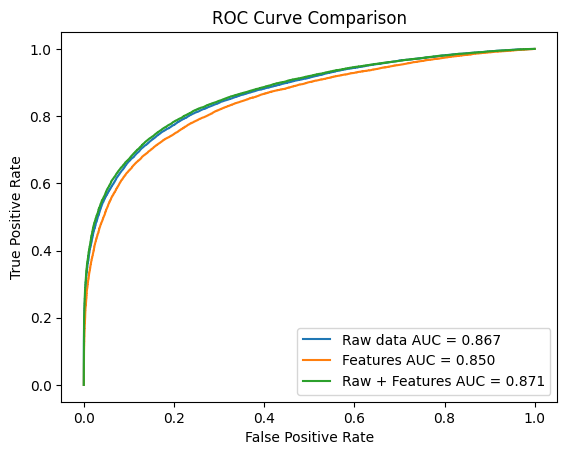

In [134]:
plt.figure()

# Plot all models
plot_roc(model_raw, X_test_raw, y_Test, "Raw data")
plot_roc(model_feat, X_test_feat, y_Test, "Features")
plot_roc(model_all, X_test_all, y_Test, "Raw + Features")

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [135]:
X_train = X_train_all
X_test = X_test_all

In [139]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Model 1: simple network
model1 = Sequential([
   Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [140]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Model 2: deeper network (more learning capacity)

model2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [141]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense, Input

# Model 3: adds dropout (helps reduce overfitting)

model3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),  # randomly ignores some neurons during training
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [142]:
h1 = model1.fit(
    X_train, y_Train,
    validation_data=(X_test, y_Test),
    epochs=5,
    batch_size=256,
    verbose=0
)

h2 = model2.fit(
    X_train, y_Train,
    validation_data=(X_test, y_Test),
    epochs=5,
    batch_size=256,
    verbose=0
)

h3 = model3.fit(
    X_train, y_Train,
    validation_data=(X_test, y_Test),
    epochs=5,
    batch_size=256,
    verbose=0
)

In [143]:
print("Model 1 Accuracy:", h1.history['val_accuracy'][-1])
print("Model 2 Accuracy:", h2.history['val_accuracy'][-1])
print("Model 3 Accuracy:", h3.history['val_accuracy'][-1])

Model 1 Accuracy: 0.7977399826049805
Model 2 Accuracy: 0.7990599870681763
Model 3 Accuracy: 0.797980010509491


## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [144]:
# From Exercise 3, Model 2 performed best
best_dnn = model2

In [145]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [148]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train the model using the training data
    if not hasattr(model, "history"):  # sklearn models
      model.fit(X_train, y_train)

    # Get prediction scores from the model

    # If the model can give probabilities (like Logistic Regression, LDA, Naive Bayes)
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]  # take probability of class 1

    # If it is a neural network (DNN), use predict instead
    else:
        scores = model.predict(X_test).ravel()

    # Create ROC curve (shows how well model separates classes)
    fpr, tpr, _ = roc_curve(y_test, scores)

    # AUC score = single number that measures performance
    # Higher AUC = better model
    roc_auc = auc(fpr, tpr)

    # Return results so we can plot them later
    return fpr, tpr, roc_auc

In [149]:
lda = LinearDiscriminantAnalysis()
log_reg = LogisticRegression(max_iter=1000)
nb = GaussianNB()

# Best deep learning model from exercise 3
dnn = best_dnn

In [150]:
fpr_lda, tpr_lda, auc_lda = evaluate_model(lda, X_Train, y_Train, X_Test, y_Test)
fpr_lr, tpr_lr, auc_lr = evaluate_model(log_reg, X_Train, y_Train, X_Test, y_Test)
fpr_nb, tpr_nb, auc_nb = evaluate_model(nb, X_Train, y_Train, X_Test, y_Test)

# Model 2 DNN
fpr_dnn, tpr_dnn, auc_dnn = evaluate_model(dnn, X_Train, y_Train, X_Test, y_Test)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [151]:
print("AUC Summary:")
print("LDA:", auc_lda)
print("LogReg:", auc_lr)
print("Naive Bayes:", auc_nb)
print("DNN:", auc_dnn)

AUC Summary:
LDA: 0.8366318362375931
LogReg: 0.8564820861017896
Naive Bayes: 0.8112670873971662
DNN: 0.8733055969971955


In [152]:
# In this lab, deep neural networks were used to classify signal vs background events.
# The model performance improved when using both raw and engineered features together.
# Different network architectures were tested, and a moderately deep model performed best.
# Overall, the deep neural network achieved better performance than traditional machine learning methods.